# 3. Análisis Bivariado
---

## 1. Introducción

En el contexto de la tarificación de seguros de automóviles, se analizará de manera diferenciada la frecuencia y la severidad de los siniestros, considerando la tasa de frecuencia como medida de ocurrencia y el monto de los siniestros como medida de costo. Este análisis busca identificar patrones y asociaciones entre estas variables y las características de los asegurados y vehículos, proporcionando una base descriptiva para comprender los factores relacionados con el costo esperado del riesgo y su posterior aplicación en la tarificación actuarial.

## 2. Objetivo del análisis Bivariado

Estudiar la relación entre las variables explicativas y las variables asociadas al riesgo asegurado, especialmente el número de siniestros (ClaimNb) y la exposición (Exposure), con el fin de identificar patrones, asociaciones y posibles factores relacionados con la frecuencia de siniestros.  

**Marco Conceptual:**  

* **Tasa de Frecuencia ($\lambda$):** Número esperado de siniestros por unidad de tiempo expuesto al riesgo. Se evalúa sobre la totalidad de las pólizas observadas ($N \ge 0$) mediante la relación:

$$\lambda = \frac{\sum_{i} \text{ClaimNb}_i}{\sum_{i} \text{Exposure}_i}$$

* **Severidad Promedio ($S$):** Costo monetario medio condicionado a la ocurrencia de al menos un siniestro. Se evalúa únicamente sobre las observaciones con siniestralidad registrada ($N > 0$):

$$S = \frac{\sum_{j} \text{ClaimAmount}_j}{\sum_{j} \text{ClaimNb}_j} \quad \text{para } \text{ClaimNb}_j > 0$$

* **Prima Pura Observada ($P$):** Costo esperado del riesgo por unidad de exposición, resultante del producto entre la frecuencia esperada y la severidad promedio:

$$P = \lambda \times S = \frac{\sum_{i} \text{ClaimAmountTotal}_i}{\sum_{i} \text{Exposure}_i}$$

Esta descomposición permite determinar si el nivel de riesgo de un determinado segmento responde a una mayor recurrencia de eventos (alta frecuencia), a un costo elevado por reclamo (alta severidad) o a una combinación de ambos factores.


In [ ]:
#Carga de datos
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%load_ext autoreload
%autoreload 2

sys.path.append(str(Path("..").resolve()))
from src.utils import set_plot_style, load_freq, load_sev, hist_box, tabla_frecuencias, ecdf

set_plot_style()
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


col_rename = {
    "IDpol": "id_poliza",
    "ClaimNb": "num_siniestros",
    "Exposure": "exposicion",
    "Area": "area",
    "VehPower": "potencia_vehiculo",
    "VehAge": "edad_vehiculo",
    "DrivAge": "edad_conductor",
    "BonusMalus": "bonus_malus",
    "VehBrand": "marca_vehiculo",
    "VehGas": "tipo_combustible",
    "Density": "densidad_poblacion",
    "Region": "region",
    "ClaimAmount": "monto_siniestro"
}

df_freq = load_freq("freMTPL2freq.csv").rename(columns=col_rename)
df_sev = load_sev("freMTPL2sev.csv").rename(columns=col_rename)

# Cálculo de la tasa de frecuencia con los nuevos nombres
df_freq["tasa_frecuencia"] = df_freq["num_siniestros"] / df_freq["exposicion"]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
df_freq.head()

,id_poliza,exposicion,area,potencia_vehiculo,edad_vehiculo,edad_conductor,bonus_malus,marca_vehiculo,tipo_combustible,densidad_poblacion,region,num_siniestros,tasa_frecuencia
0,1,0.1000,D,5,0,55,50,B12,Regular,1217,R82,0,0.0000
1,3,0.7700,D,5,0,55,50,B12,Regular,1217,R82,0,0.0000
2,5,0.7500,B,6,2,52,50,B12,Diesel,54,R22,0,0.0000
3,10,0.0900,B,7,0,46,50,B12,Diesel,76,R72,0,0.0000
4,11,0.8400,B,7,0,46,50,B12,Diesel,76,R72,0,0.0000


In [19]:
print("Dimensiones frecuencia:", df_freq.shape)
print("Dimensiones severidad:", df_sev.shape)

print("\nVariables de frecuencia:")
print(df_freq.columns.tolist())

print("\nVariables de severidad:")
print(df_sev.columns.tolist())

Dimensiones frecuencia: (678007, 13)
Dimensiones severidad: (24938, 2)

Variables de frecuencia:
['id_poliza', 'exposicion', 'area', 'potencia_vehiculo', 'edad_vehiculo', 'edad_conductor', 'bonus_malus', 'marca_vehiculo', 'tipo_combustible', 'densidad_poblacion', 'region', 'num_siniestros', 'tasa_frecuencia']

Variables de severidad:
['id_poliza', 'monto_siniestro']


## 3. Definición de variables  

**Variables de respuesta:**   

- ClaimRate: tasa de frecuencia 
- ClaimAmount: monto del siniestro  

**Numéricas:**  

- Exposure
- VehPower
- VehAge
- DrivAge
- BonusMalus
- Density
- ClaimNb

**Categóricas:**  

- Area
- VehBrand
- VehGas
- Region 

## 4. Análisis de Frecuencia  

Se usará la variable ClaimRate para medir la frecuencia, dado que, según lo visto en el análisis univariado ClaimNb dice cuántos siniestros ocurrieron; en cambio, ClaimRate permite comparar correctamente la frecuencia teniendo en cuenta cuánto tiempo estuvo expuesto cada riesgo.  

### 4.1 **tasa_frecuencia vs variables numéricas** 

Se examina la relación entre tasa_frecuencia y las cuatro variables numéricas identificadas en el análisis univariado: edad_vehiculo, edad_conductor, bonus_malus y densidad_poblacion. A diferencia del análisis univariado, aquí el interés no es la distribución individual de cada variable, sino su posible asociación con la frecuencia de siniestralidad, insumo directo para la selección de variables explicativas en la etapa de modelación.

#### **Visualización con gráfico de dispersión** 

Se construyen gráficos de dispersión en escala semilogarítmica para evaluar la relación individual entre cada variable numérica de la cartera y la tasa de frecuencia de siniestros, filtrando únicamente las pólizas con siniestralidad registrada.Dado que, la transformación logarítmica en el eje vertical comprime los valores atípicos extremos (generados por pólizas con exposición fraccionada) y previene el colapso visual de los datos. Esto permite inspeccionar la dispersión, el comportamiento en los extremos y la densidad de observaciones a nivel micro sin perder la escala de los valores reales.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr
from scipy.stats import mannwhitneyu
from scipy.stats import kruskal
from scipy.stats import chi2_contingency

In [25]:
#Variables numéricas  

numeric_freq = [
    "edad_vehiculo",
    "edad_conductor",
    "bonus_malus",
    "densidad_poblacion"
]

Para cada variable numérica se construye un diagrama de dispersión contra "tasa_frecuencia", restringido a las pólizas que efectivamente registraron al menos un siniestro. Esta decisión responde a que la gran mayoría de las pólizas presenta "tasa_frecuencia = 0" (recordando la fuerte concentración en cero observada en el análisis univariado de "ClaimNb"), por lo que incluir esas observaciones saturaría el gráfico sin aportar información sobre el patrón de asociación. Se utiliza una escala logarítmica en el eje Y dado el amplio rango de valores que puede tomar la tasa de frecuencia individual.

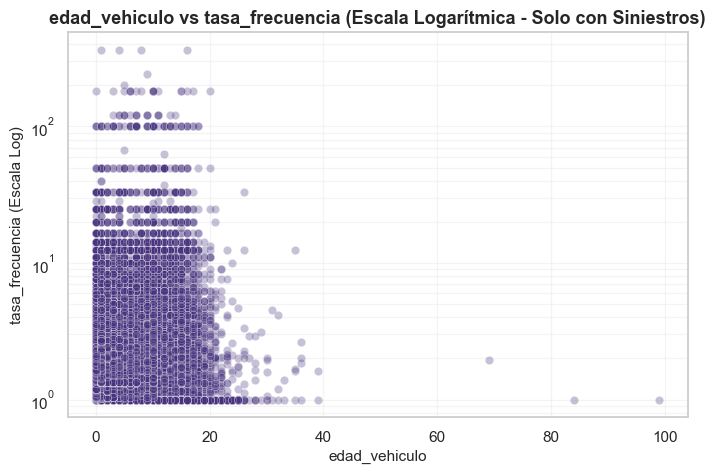

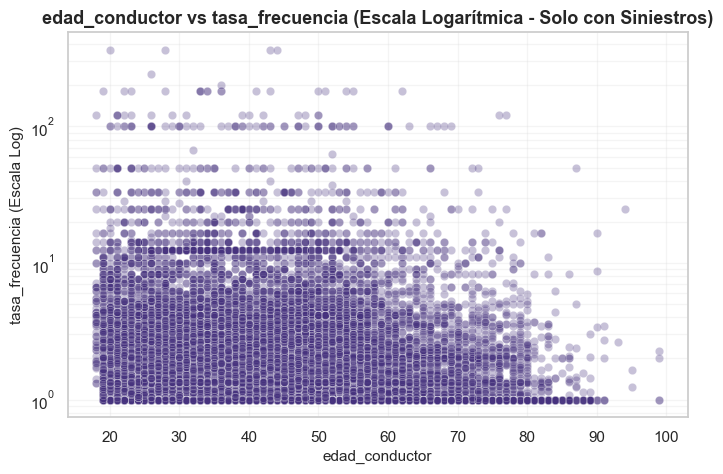

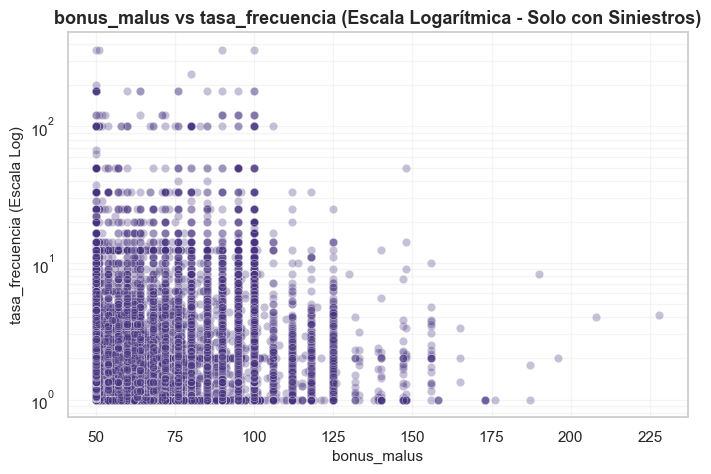

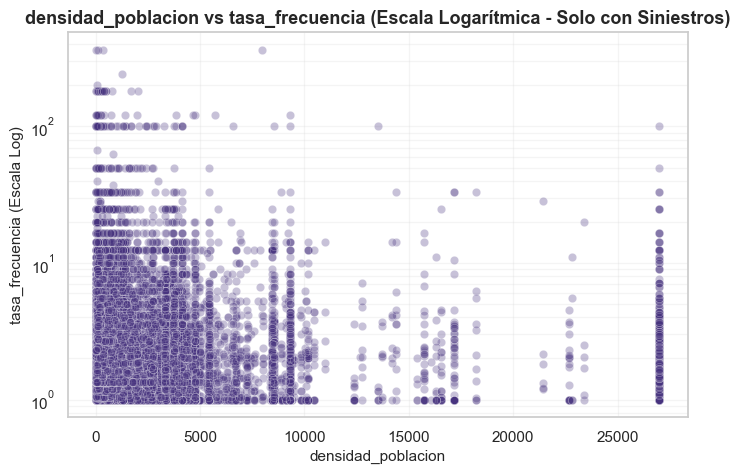

In [29]:
for var in numeric_freq:
    
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=df_freq[df_freq["num_siniestros"] > 0],  # Inspección de casos con siniestralidad
        x=var,
        y="tasa_frecuencia",
        alpha=0.3
    )
    
    plt.yscale("log")  # Escala logarítmica directa en el eje Y
    plt.title(f"{var} vs tasa_frecuencia (Escala Logarítmica - Solo con Siniestros)")
    plt.xlabel(var)
    plt.ylabel("tasa_frecuencia (Escala Log)")
    plt.grid(alpha=0.2, which="both")
    plt.show()

- Edad del Vehículo: La siniestralidad registrada se agrupa de forma masiva en automóviles de entre $0$ y $15$ años de antigüedad, donde la densidad de puntos es máxima y se observan las tasas de frecuencia individuales más elevadas ($10^0$ a $10^2$). Superados los $20$ años de uso, la cantidad de siniestros decae drásticamente y la tasa de frecuencia máxima se estabiliza cerca del límite inferior ($10^0$), reflejando la baja presencia de vehículos antiguos o de colección dentro de la cartera asegurada y su menor exposición real al riesgo.  
- Edad del Conductor: La siniestralidad se concentra masivamente en conductores de entre $20$ y $50$ años, donde la densidad de puntos es más densa y alcanza tasas de frecuencia que varían desde $1$ hasta picos anómalos superiores a $100$ (debido a exposiciones fraccionadas). A partir de los $60$ años, la densidad de eventos disminuye gradualmente, y en conductores mayores de $80$ años la siniestralidad registrada es notablemente escasa, con tasas individuales estabilizadas en el rango bajo ($10^0$).  
- Bonus-Malus: La inmensa mayoría de las pólizas con siniestros reportados se agrupan en el rango de bonificación (entre $50$ y $100$), reflejando que la mayoría de los accidentes ocurren en conductores que previamente tenían buen historial. Sin embargo, a medida que el factor de penalización supera el umbral base ($100$ hacia $225$), la dispersión se vuelve menos densa, indicando que existen pocos conductores altamente penalizados en la cartera, aunque los que permanecen siguen registrando siniestros consistentes.  
- Densidad de Población: Existe una aglomeración extrema de siniestros en zonas de baja densidad poblacional (menos de $5,000$ habitantes/$\text{km}^2$), lo que representa la mayor parte del volumen de la cartera fuera de las áreas metropolitanas. A medida que la densidad aumenta hacia niveles hiperurbanos ($>20,000$, típicamente París y alrededores), el volumen total de pólizas disminuye, pero persisten tasas de siniestralidad individuales elevadas e incluso una columna de concentración anómala alrededor de los $27,000$, lo cual sugiere un límite artificial (saturación de medición o tope de registro) en los datos geográficos franceses para zonas ultra-densas.  

Además, se puede visualizar una posible ausencia de linealidad directa.

#### **Correlación** 

Se calcula el coeficiente de correlación de Spearman ($\rho$) entre cada variable numérica y tasa_frecuencia. Se elige esta medida sobre el coeficiente de Pearson porque no asume una relación lineal ni distribuciones normales, condiciones que claramente no se cumplen dado el fuerte sesgo hacia cero de la variable de frecuencia. Además, Spearman captura relaciones monótonas(aquella en la que ambas se mueven de manera constante en una sola dirección, ya sea subiendo o bajando juntas, sin cambiar de rumbo) no necesariamente lineales, lo cual resulta más apropiado en el contexto de variables actuariales como bonus_malus, cuya relación con el riesgo suele ser progresiva pero no estrictamente proporcional.

In [31]:
resultados_spearman_freq = []

for var in numeric_freq:
    
    temp = df_freq[[var, "tasa_frecuencia"]].dropna()
    
    rho, pvalue = spearmanr(
        temp[var],
        temp["tasa_frecuencia"]
    )
    
    resultados_spearman_freq.append({
        "Variable": var,
        "Spearman_rho": rho,
        "p_value": pvalue,
        "N": len(temp)
    })

spearman_freq = pd.DataFrame(resultados_spearman_freq)

spearman_freq.sort_values(
    "Spearman_rho",
    key=abs,
    ascending=False
)

,Variable,Spearman_rho,p_value,N
2,bonus_malus,0.0573,0.0000,678007
3,densidad_poblacion,0.0203,0.0000,678007
0,edad_vehiculo,0.0195,0.0000,678007
1,edad_conductor,-0.0054,0.0000,678007


Se observa que todas las variables numéricas presentan coeficientes extremadamente cercanos a cero ($\rho$ entre $-0.0054$ y $0.0573$), evidenciando la ausencia de una relación monótona o lineal directa con la tasa de frecuencia calculada individualmente. Sin embargo, dentro de las métricas obtenidas, la variable bonus_malus registra la asociación positiva más alta ($\rho = 0.0573$), revalidando que el historial de penalizaciones es el predictor directo de mayor impacto relativo.   
Cabe resaltar que los $p$-valores resultan ser estrictamente significativos ($p < 0.0001$) donde la hipótesis nula es: "no existe una correlación de rangos (asociación monótona) en la población entre la variable explicativa evaluada y la tasa de frecuencia ($\rho = 0$)", este comportamiento es un artefacto metodológico derivado del elevado tamaño muestral ($N = 678,007$).  

### 4.2 **ClaimRate vs variables categóricas** 

Se analiza la relación entre tasa_frecuencia y las variables categóricas area, potencia_vehiculo, marca_vehiculo, tipo_combustible y region. Como primer paso, se presenta la distribución de pólizas dentro de cada categoría (conteo, porcentaje y porcentaje acumulado), con el fin de identificar categorías con baja representación que podrían requerir agrupación antes de avanzar hacia comparaciones de tasas o pruebas estadísticas. 

**Vista por categorías**

In [32]:
categorical_freq = [
    "area",
    "potencia_vehiculo",
    "marca_vehiculo",
    "tipo_combustible",
    "region"
]

In [36]:
for var in categorical_freq:
    df_resumen = (
        df_freq[var]
        .value_counts(dropna=False)
        .reset_index()
    )
    df_resumen.columns = [var, "Conteo"]
    df_resumen["Porcentaje (%)"] = (df_resumen["Conteo"] / len(df_freq)) * 100
    df_resumen["% Acumulado"] = df_resumen["Porcentaje (%)"].cumsum()
    
    # Formatear números
    df_resumen["Conteo"] = df_resumen["Conteo"].apply(lambda x: f"{x:,}")
    df_resumen["Porcentaje (%)"] = df_resumen["Porcentaje (%)"].map("{:.2f}%".format)
    df_resumen["% Acumulado"] = df_resumen["% Acumulado"].map("{:.2f}%".format)
    
    # Mostrar la tabla formateada
    display(df_resumen)

,area,Conteo,Porcentaje (%),% Acumulado
0,C,"191,880",28.30%,28.30%
1,D,"151,590",22.36%,50.66%
2,E,"137,167",20.23%,70.89%
3,A,"103,957",15.33%,86.22%
4,B,"75,459",11.13%,97.35%
5,F,"17,954",2.65%,100.00%


,potencia_vehiculo,Conteo,Porcentaje (%),% Acumulado
0,6,"148,976",21.97%,21.97%
1,7,"145,401",21.45%,43.42%
2,5,"124,821",18.41%,61.83%
3,4,"115,343",17.01%,78.84%
4,8,"46,956",6.93%,85.77%
5,10,"31,354",4.62%,90.39%
6,9,"30,085",4.44%,94.83%
7,11,"18,352",2.71%,97.53%
8,12,"8,214",1.21%,98.75%
9,13,"3,229",0.48%,99.22%


,marca_vehiculo,Conteo,Porcentaje (%),% Acumulado
0,B12,"166,024",24.49%,24.49%
1,B1,"162,730",24.00%,48.49%
2,B2,"159,861",23.58%,72.07%
3,B3,"53,395",7.88%,79.94%
4,B5,"34,753",5.13%,85.07%
5,B6,"28,548",4.21%,89.28%
6,B4,"25,179",3.71%,92.99%
7,B10,"17,707",2.61%,95.60%
8,B11,"13,585",2.00%,97.61%
9,B13,"12,178",1.80%,99.40%


,tipo_combustible,Conteo,Porcentaje (%),% Acumulado
0,Regular,"345,871",51.01%,51.01%
1,Diesel,"332,136",48.99%,100.00%


,region,Conteo,Porcentaje (%),% Acumulado
0,R24,"160,601",23.69%,23.69%
1,R82,"84,752",12.50%,36.19%
2,R93,"79,315",11.70%,47.89%
3,R11,"69,791",10.29%,58.18%
4,R53,"42,122",6.21%,64.39%
5,R52,"38,751",5.72%,70.11%
6,R91,"35,799",5.28%,75.39%
7,R72,"31,329",4.62%,80.01%
8,R31,"27,285",4.02%,84.03%
9,R54,"19,046",2.81%,86.84%


#### **Tasa agregada de frecuencia por categoría**  

A diferencia de calcular el promedio simple de "tasa_frecuencia" por categoría, que ponderaría por igual pólizas con exposiciones muy distintas, se construye una tasa agregada por grupo: la razón entre la suma total de siniestros y la suma total de exposición dentro de cada categoría. Dado que, esta es la forma estándar en ciencia actuarial de calcular una frecuencia de siniestralidad representativa a nivel de grupo, ya que pondera correctamente el aporte de cada póliza según el tiempo real que estuvo expuesta al riesgo, evitando que pólizas con exposiciones muy cortas (y por tanto tasas individuales potencialmente extremas) distorsionen el promedio.  

In [43]:
def calcular_tasa_por_grupo(df, variable):
    
    resultado = (
        df.groupby(variable)
        .agg(
            num_siniestros=("num_siniestros", "sum"),
            exposicion=("exposicion", "sum"),
            num_polizas=("id_poliza", "count")
        )
        .reset_index()
    )
    
    resultado["tasa_frecuencia"] = (
        resultado["num_siniestros"] /
        resultado["exposicion"]
    )
    
    return resultado

In [45]:

for var in categorical_freq:
    
    resultado = calcular_tasa_por_grupo(
        df_freq,
        var
    )

    print(f"TASA DE FRECUENCIA POR: {var}")
    
    display(
        resultado.sort_values(
            "tasa_frecuencia",
            ascending=False
        )
    )

TASA DE FRECUENCIA POR: area


,area,num_siniestros,exposicion,num_polizas,tasa_frecuencia
4,E,6122,"63,785.6943",137167,0.0960
5,F,774,"8,125.4341",17954,0.0953
3,D,6397,"77,086.5017",151590,0.0830
2,C,7093,"104,402.5238",191880,0.0679
1,B,2633,"43,001.8239",75459,0.0612
0,A,3364,"61,956.8277",103957,0.0543


TASA DE FRECUENCIA POR: potencia_vehiculo


,potencia_vehiculo,num_siniestros,exposicion,num_polizas,tasa_frecuencia
10,14,101,"1,180.0204",2350,0.0856
9,13,139,"1,637.0353",3229,0.0849
7,11,714,"8,491.3085",18352,0.0841
5,9,1220,"15,338.6437",30085,0.0795
6,10,1217,"15,367.0908",31354,0.0792
8,12,296,"3,790.7983",8214,0.0781
2,6,6305,"82,497.5902",148976,0.0764
11,15,96,"1,260.4492",2926,0.0762
1,5,5115,"68,148.1288",124821,0.0751
4,8,1645,"22,673.9663",46956,0.0726


TASA DE FRECUENCIA POR: marca_vehiculo


,marca_vehiculo,num_siniestros,exposicion,num_polizas,tasa_frecuencia
2,B11,664,"6,883.0773",13585,0.0965
7,B3,2429,"28,576.4363",53395,0.0850
9,B5,1662,"19,983.6027",34753,0.0832
1,B10,765,"9,489.8441",17707,0.0806
10,B6,1252,"15,677.4236",28548,0.0799
8,B4,1099,"13,770.0561",25179,0.0798
4,B13,539,"6,768.0322",12178,0.0796
6,B2,6805,"94,823.7571",159861,0.0718
0,B1,6837,"95,313.6896",162730,0.0717
3,B12,4200,"64,802.3787",166024,0.0648


TASA DE FRECUENCIA POR: tipo_combustible


,tipo_combustible,num_siniestros,exposicion,num_polizas,tasa_frecuencia
0,Diesel,13450,"170,587.5531",332136,0.0788
1,Regular,12933,"187,771.2523",345871,0.0689


TASA DE FRECUENCIA POR: region


,region,num_siniestros,exposicion,num_polizas,tasa_frecuencia
17,R82,4233,"45,332.5873",84752,0.0934
2,R22,314,"3,572.8402",7994,0.0879
0,R11,2591,"30,198.1320",69791,0.0858
20,R93,2986,"35,748.9810",79315,0.0835
16,R74,197,"2,395.7345",4567,0.0822
7,R31,944,"11,488.0743",27285,0.0822
9,R42,92,"1,208.6358",2200,0.0761
21,R94,132,"1,765.9354",4516,0.0747
14,R72,1055,"14,316.1667",31329,0.0737
11,R52,1576,"21,930.3212",38751,0.0719


En "area", la tasa de frecuencia aumenta de forma consistente desde la categoría A (0.0543) hasta E (0.0960), con F muy cerca del máximo (0.0953) pero con una exposición considerablemente menor (8,125 años-póliza frente a los más de 60,000 de las demás categorías), lo que exige cautela al interpretar su tasa como igualmente confiable. En "potencia_vehiculo" se observa una tendencia levemente creciente con la potencia (de 0.0656 en potencia 4 hasta 0.0856 en potencia 14), aunque con ruido notable en las categorías de mayor potencia, que concentran muy pocas pólizas (por debajo de 3,000 años-póliza). En "marca_vehiculo" no se aprecia un patrón interpretable más allá de las diferencias numéricas, al tratarse de categorías anonimizadas, la variación entre B11 (0.0965, la más alta) y B14 (0.0577, la más baja) no puede vincularse a una característica de marca real. "tipo_combustible" muestra una diferencia moderada pero consistente: los vehículos diésel presentan una tasa mayor (0.0788) que los de gasolina (0.0689). Finalmente, en "region" destaca R82 con la tasa más alta (0.0934), mientras que R24, a pesar de ser, con diferencia, la región con más pólizas de la cartera (23.69% del total), presenta una tasa relativamente baja (0.0630), evidenciando que el tamaño de la cartera en una región no está necesariamente asociado con un mayor riesgo relativo.

#### **Gráfico de tasa de frecuencia por categoría**  

Se visualiza la tasa agregada de frecuencia calculada para cada variable categórica mediante gráficos de barras interactivos, ordenados de mayor a menor tasa.  

In [50]:
import plotly.express as px

for var in categorical_freq:
    
    resultado = calcular_tasa_por_grupo(df_freq, var)
    
    # Ordenar por tasa de frecuencia descendente
    resultado_sorted = resultado.sort_values("tasa_frecuencia", ascending=False)
    
    # Crear gráfico interactivo de barras
    fig = px.bar(
        resultado_sorted,
        x=var,
        y="tasa_frecuencia",
        color="tasa_frecuencia",
        color_continuous_scale="Purples",  # Escala de morados
        title=f"Tasa de frecuencia por {var}",
        labels={
            var: var,
            "tasa_frecuencia": "Tasa de Frecuencia"
        },
        # hover_data permite añadir campos adicionales como el conteo de pólizas o siniestros si existen en el df
        hover_data=resultado_sorted.columns 
    )
    
    # Formato y estilo visual
    fig.update_layout(
        template="plotly_white",
        xaxis_title=var,
        yaxis_title="Tasa de frecuencia",
        xaxis_tickangle=-45,
        coloraxis_showscale=False  # Oculta la barra de color lateral
    )
    
    # Personalizar la etiqueta que se muestra al pasar el ratón
    fig.update_traces(
        hovertemplate="<b>%{x}</b><br>Tasa Frecuencia: %{y:.4f}<extra></extra>"
    )
    
    fig.show()

La visualización interactiva confirma visualmente los mismos patrones identificados en las tablas: un gradiente claro y ordenado en "area" (de A a E/F), una tendencia más ruidosa pero perceptible en "potencia_vehiculo", y una dispersión considerable sin un patrón evidente en "marca_vehiculo" y "region", donde las categorías de mayor y menor tasa no siguen ningún orden natural aparente. Este contraste visual refuerza la idea de que "area" y, en menor medida, "potencia_vehiculo" podrían aportar señal más sistemática al modelo de frecuencia que "marca_vehiculo" o "region", cuya variabilidad luce más cercana al ruido entre categorías con exposiciones desiguales.

#### **Pruebas estadísticas**  

Se contrasta formalmente si existen diferencias estadísticamente significativas en "tasa_frecuencia" entre las categorías de cada variable. Para variables con exactamente dos grupos (tipo_combustible) se aplica la prueba de Mann-Whitney U; para variables con tres o más grupos (area, potencia_vehiculo, marca_vehiculo, region) se aplica la prueba de Kruskal-Wallis. Dado que, ambas son pruebas no paramétricas que no requieren el supuesto de normalidad, condición que como ya se evidenció en el análisis univariado, no se cumple para las variables de siniestralidad, marcadas por una fuerte asimetría y una alta concentración de ceros.

In [51]:
def mann_whitney_tasa(df, variable):
    
    temp = df[
        [variable, "tasa_frecuencia"]
    ].dropna()
    
    grupos = temp[variable].unique()
    
    if len(grupos) != 2:
        return None
    
    grupo1 = temp[
        temp[variable] == grupos[0]
    ]["tasa_frecuencia"]
    
    grupo2 = temp[
        temp[variable] == grupos[1]
    ]["tasa_frecuencia"]
    
    statistic, pvalue = stats.mannwhitneyu(
        grupo1,
        grupo2,
        alternative="two-sided"
    )
    
    return {
        "variable": variable,
        "grupo_1": grupos[0],
        "grupo_2": grupos[1],
        "U": statistic,
        "p_value": pvalue
    }
def kruskal_tasa(df, variable):
    
    temp = df[
        [variable, "tasa_frecuencia"]
    ].dropna()
    
    grupos = [
        grupo["tasa_frecuencia"].values
        for _, grupo in temp.groupby(variable)
    ]
    
    statistic, pvalue = stats.kruskal(*grupos)
    
    return {
        "variable": variable,
        "H": statistic,
        "p_value": pvalue,
        "num_grupos": len(grupos)
    }

In [ ]:
resultados_pruebas_freq = []

for var in categorical_freq:
    
    temp = df_freq[
        [var, "tasa_frecuencia"]
    ].dropna()
    
    num_grupos = temp[var].nunique()
    
    grupos = [
        grupo["tasa_frecuencia"].values
        for _, grupo in temp.groupby(var)
    ]
    
    if num_grupos == 2:
        
        statistic, pvalue = stats.mannwhitneyu(
            grupos[0],
            grupos[1],
            alternative="two-sided"
        )
        
        prueba = "Mann-Whitney"
        estadistico = statistic
        
    else:
        
        statistic, pvalue = stats.kruskal(*grupos)
        
        prueba = "Kruskal-Wallis"
        estadistico = statistic
    
    resultados_pruebas_freq.append({
        "variable": var,
        "prueba": prueba,
        "estadistico": estadistico,
        "p_value": pvalue,
        "num_grupos": num_grupos
    })

pruebas_freq = pd.DataFrame(
    resultados_pruebas_freq
)

pruebas_freq

,variable,prueba,estadistico,p_value,num_grupos
0,area,Kruskal-Wallis,274.2422,0.0000,6
1,potencia_vehiculo,Kruskal-Wallis,154.3319,0.0000,12
2,marca_vehiculo,Kruskal-Wallis,"1,190.4085",0.0000,11
3,tipo_combustible,Mann-Whitney,"57,602,200,985.5000",0.0000,2
4,region,Kruskal-Wallis,741.5618,0.0000,22


Las cinco variables categóricas muestran diferencias estadísticamente significativas en "tasa_frecuencia" entre sus grupos: "area" (Kruskal-Wallis H = 274.24), "potencia_vehiculo" (H = 154.33), "marca_vehiculo" (H = 1,190.41), "tipo_combustible" (Mann-Whitney U = 57,602,200,985.5) y "region" (H = 741.56), todas con p-valor menor a 0.0001. Sin embargo, este resultado debe leerse con cautela: con un tamaño muestral de 678,007 observaciones, prácticamente cualquier diferencia entre grupos, por mínima que sea, resulta estadísticamente significativa, aun cuando su magnitud práctica sea pequeña, como ya lo sugerían los coeficientes de Spearman cercanos a cero para las variables numéricas. La significancia estadística confirma que las diferencias observadas no son producto del azar, pero no garantiza por sí sola que esas variables tengan un poder predictivo relevante para el modelo de frecuencia; esa evaluación corresponderá a la etapa de modelación, donde se medirá el aporte real de cada variable controlando por las demás.

## 5. Análisis de Severidad  

Para el análisis de severidad la variable objetivo es "monto_siniestro", definida únicamente sobre las pólizas que efectivamente registraron al menos un siniestro (`df_sev`). A diferencia del análisis de frecuencia, aquí no se pondera por exposición, ya que el monto de un siniestro es independiente del tiempo que la póliza estuvo asegurada; el interés se centra en identificar qué características del vehículo, del conductor o de la ubicación geográfica están asociadas con siniestros de mayor costo.

**Descripción de la variable** 

In [54]:
df_sev["monto_siniestro"].describe()

count      24,938.0000
mean        2,397.0479
std        30,266.6188
min             1.0000
25%           749.2625
50%         1,172.0000
75%         1,346.3600
max     4,075,400.5600
Name: monto_siniestro, dtype: float64

In [56]:
df_sev["log_monto_siniestro"] = np.log1p(
    df_sev["monto_siniestro"]
)

Dada la fuerte asimetría positiva de "monto_siniestro" ya documentada en el análisis univariado (asimetría de 106.14, con la media muy por encima de la mediana), se genera adicionalmente la variable "log_monto_siniestro" mediante una transformación logarítmica ($\log(1+x)$), que se usará en paralelo con la variable original para las visualizaciones y comparaciones por grupo, permitiendo apreciar patrones que quedan ocultos por la cola extrema de valores altos en la escala original.

**Unión de severidad con características de la póliza**

Como el dataset "df_sev" contiene únicamente el identificador de la póliza y el monto del siniestro, se enlaza con "df_freq" mediante "id_poliza" para incorporar las variables explicativas (edad del vehículo, edad del conductor, bonus-malus, densidad poblacional, marca, tipo de combustible, área y región) necesarias para el análisis bivariado de severidad.

In [57]:
df_sev_full = df_sev.merge(
    df_freq,
    on="id_poliza",
    how="left",
    suffixes=("_sev", "_freq")
)

In [58]:
df_sev_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24938 entries, 0 to 24937
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_poliza            24938 non-null  int64  
 1   monto_siniestro      24938 non-null  float64
 2   log_monto_siniestro  24938 non-null  float64
 3   exposicion           24938 non-null  float64
 4   area                 24938 non-null  object 
 5   potencia_vehiculo    24938 non-null  int64  
 6   edad_vehiculo        24938 non-null  int64  
 7   edad_conductor       24938 non-null  int64  
 8   bonus_malus          24938 non-null  int64  
 9   marca_vehiculo       24938 non-null  object 
 10  tipo_combustible     24938 non-null  object 
 11  densidad_poblacion   24938 non-null  int64  
 12  region               24938 non-null  object 
 13  num_siniestros       24938 non-null  int64  
 14  tasa_frecuencia      24938 non-null  float64
dtypes: float64(4), int64(7), object(4)
m

In [59]:
df_sev_full[
    [
        "id_poliza",
        "monto_siniestro",
        "edad_vehiculo",
        "edad_conductor",
        "bonus_malus",
        "densidad_poblacion",
        "potencia_vehiculo"
    ]
].head()

,id_poliza,monto_siniestro,edad_vehiculo,edad_conductor,bonus_malus,densidad_poblacion,potencia_vehiculo
0,139,303.0000,1,61,50,27000,7
1,190,"1,981.8400",5,50,60,56,12
2,414,"1,456.5500",0,36,85,4792,4
3,424,"10,834.0000",0,51,100,27000,10
4,463,"3,986.6700",0,45,50,12,5


### 5.1 monto_siniestro vs variables numéricas

Se analiza la relación entre "monto_siniestro" y las variables numéricas "edad_vehiculo", "edad_conductor", "bonus_malus" y "densidad_poblacion", excluyendo "potencia_vehiculo" de este grupo dado que en el análisis univariado se determinó que corresponde a una variable de naturaleza categórica (ordinal, con un número reducido de valores discretos).

#### **Visualización con gráfico de dispersión**

Se presentan diagramas de dispersión de cada variable numérica contra "monto_siniestro", utilizando la totalidad de los 24,938 siniestros registrados. La alta dispersión y presencia de valores extremos esperada en este gráfico será contrastada con la misma visualización sobre la escala logarítmica en el siguiente bloque.

In [60]:
numeric_sev = [
    "edad_vehiculo",
    "edad_conductor",
    "bonus_malus",
    "densidad_poblacion"
]

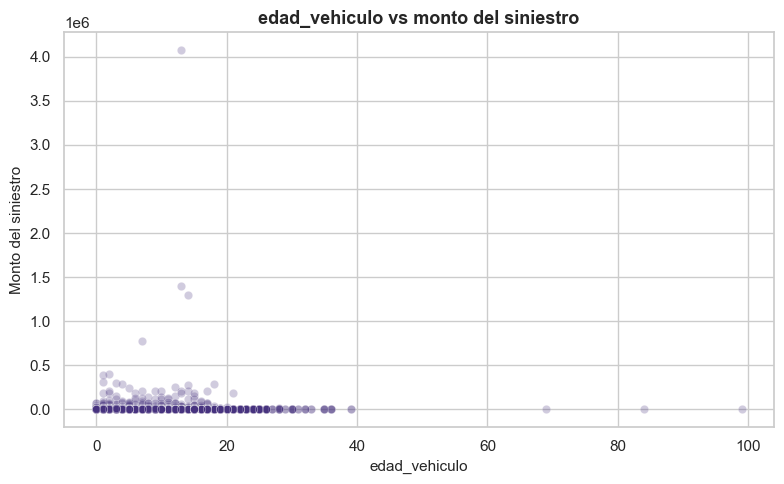

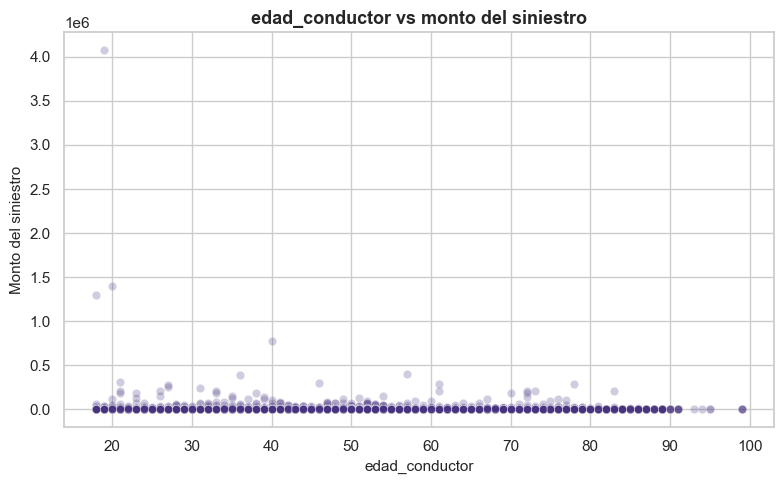

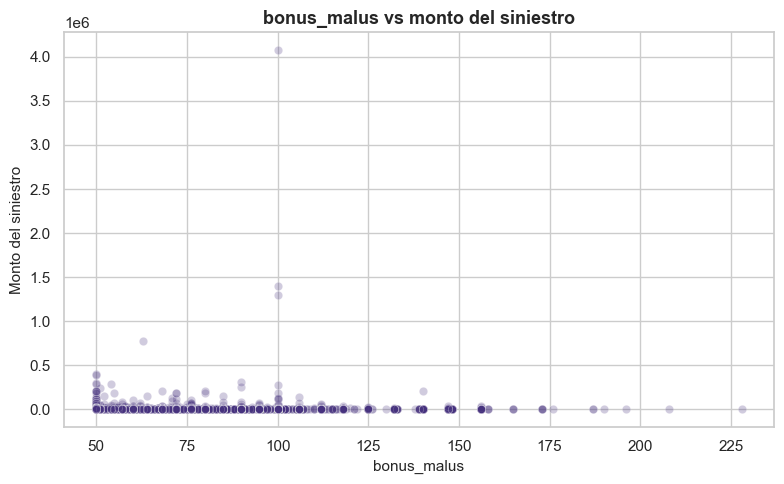

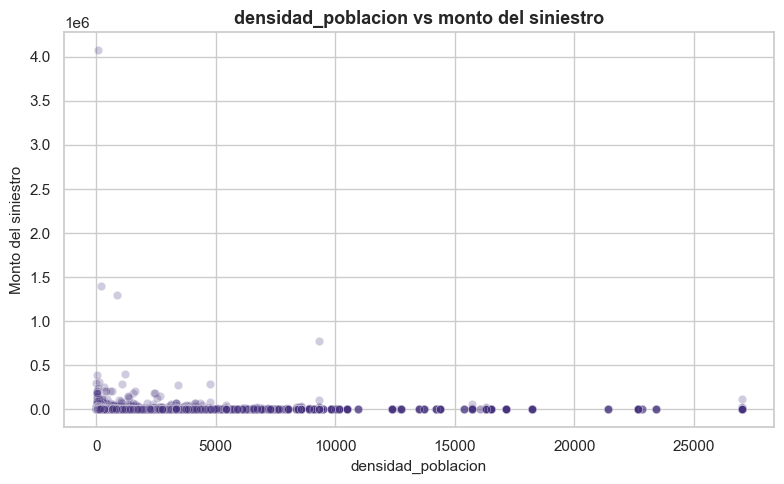

In [61]:
for var in numeric_sev:
    
    temp = df_sev_full[
        [var, "monto_siniestro"]
    ].dropna()
    
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=temp,
        x=var,
        y="monto_siniestro",
        alpha=0.25
    )
    
    plt.title(f"{var} vs monto del siniestro")
    plt.xlabel(var)
    plt.ylabel("Monto del siniestro")
    plt.tight_layout()
    plt.show()

En la escala original, los diagramas de dispersión están dominados visualmente por un número reducido de siniestros de monto extremadamente alto (hasta 4,075,400), que comprimen la mayoría de las observaciones en una franja angosta cerca del eje X y dificultan apreciar cualquier patrón entre las variables numéricas y la severidad. Al aplicar la transformación logarítmica, la nube de puntos se distribuye de forma mucho más homogénea a lo largo del rango de cada variable, y se hace evidente que la gran mayoría de los siniestros, independientemente de la edad del vehículo, la edad del conductor, el bonus-malus o la densidad poblacional, se concentra en montos moderados, mientras que los valores extremos aparecen dispersos sin una asociación visual clara con ninguna variable numérica en particular. Esto es consistente con los coeficientes de Spearman cercanos a cero: la severidad de un siniestro parece estar gobernada más por factores aleatorios o no observados (el tipo de daño, la gravedad del incidente) que por las características estructurales de la póliza.

#### **Visualización con gráfico de dispersión escala logaritmica**  

Dado que la escala original de "monto_siniestro" dificulta apreciar patrones entre los siniestros de menor cuantía, que representan la mayoría de las observaciones, se repite la visualización utilizando "log_monto_siniestro". Esta transformación comprime la escala de los valores extremos y permite examinar con mayor claridad si existe alguna tendencia entre las variables numéricas y la magnitud del siniestro.

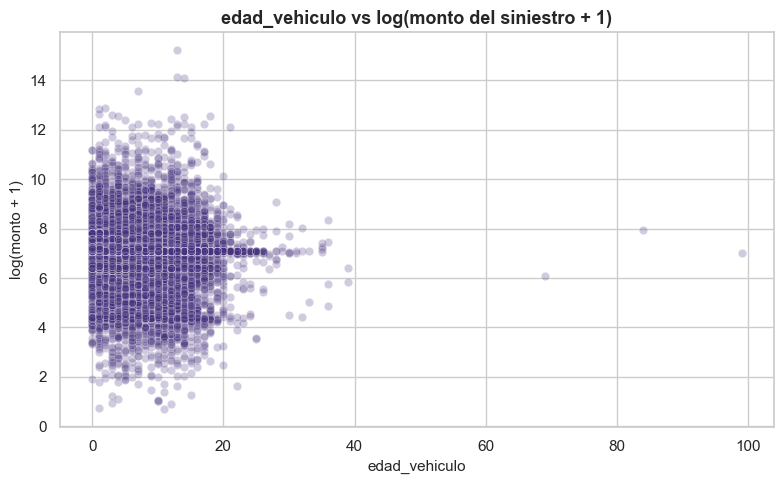

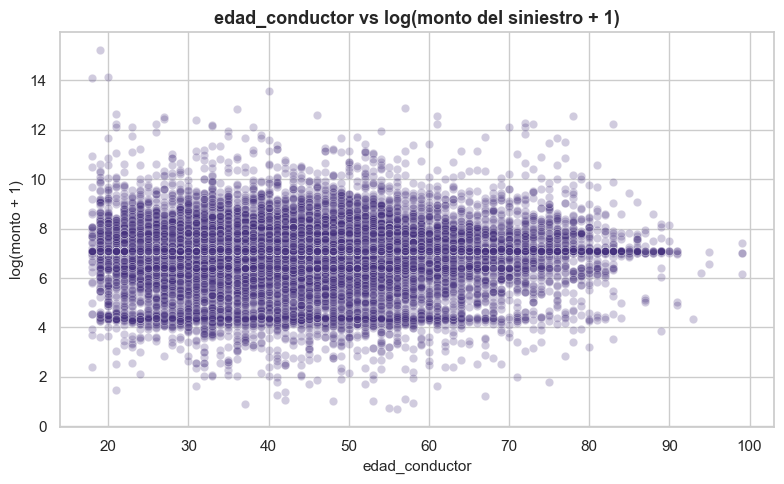

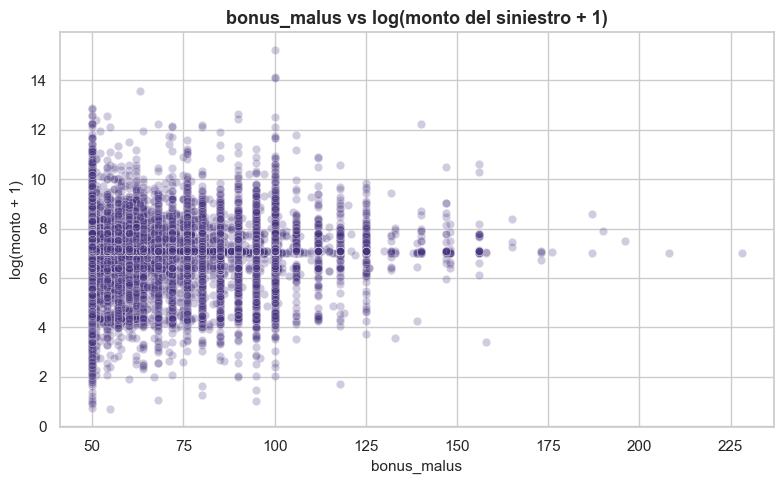

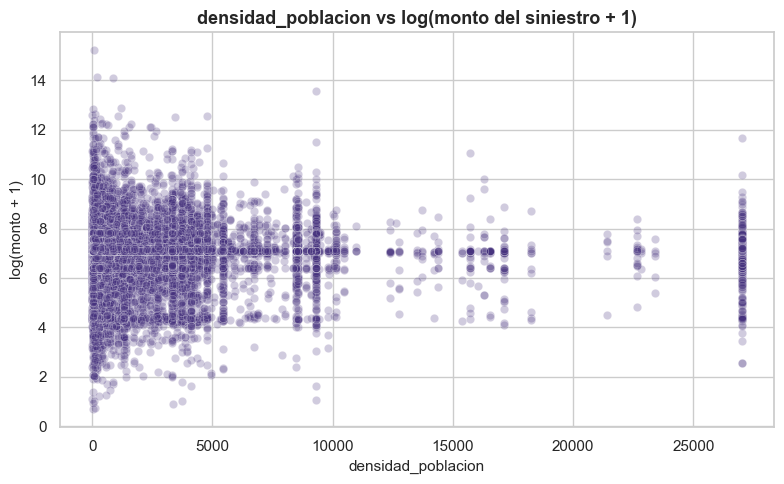

In [ ]:
for var in numeric_sev:
    
    temp = df_sev_full[
        [var, "log_monto_siniestro"]
    ].dropna()
    
    plt.figure(figsize=(8, 5))
    
    sns.scatterplot(
        data=temp,
        x=var,
        y="log_monto_siniestro",
        alpha=0.25
    )
    
    plt.title(
        f"{var} vs log(monto del siniestro + 1)"
    )
    
    plt.xlabel(var)
    plt.ylabel("log(monto + 1)")
    plt.tight_layout()
    plt.show()
    

En la escala original, los diagramas de dispersión están dominados visualmente por un número reducido de siniestros de monto extremadamente alto (hasta 4,075,400), que comprimen la mayoría de las observaciones en una franja angosta cerca del eje X y dificultan apreciar cualquier patrón entre las variables numéricas y la severidad. Al aplicar la transformación logarítmica, la nube de puntos se distribuye de forma mucho más homogénea a lo largo del rango de cada variable, y se hace evidente que la gran mayoría de los siniestros, independientemente de la edad del vehículo, la edad del conductor, el bonus-malus o la densidad poblacional, se concentra en montos moderados, mientras que los valores extremos aparecen dispersos sin una asociación visual clara con ninguna variable numérica en particular. Esto es consistente con los coeficientes de Spearman cercanos a cero: la severidad de un siniestro parece estar gobernada más por factores aleatorios o no observados (el tipo de daño, la gravedad del incidente) que por las características estructurales de la póliza.

#### **Correlación**   

Al igual que en el análisis de frecuencia, se utiliza el coeficiente de correlación de Spearman para cuantificar la asociación entre cada variable numérica y "monto_siniestro", dado que esta última tampoco cumple los supuestos de normalidad y linealidad requeridos por el coeficiente de Pearson.  

In [63]:
resultados_spearman_sev = []

for var in numeric_sev:
    
    temp = df_sev_full[
        [var, "monto_siniestro"]
    ].dropna()
    
    rho, pvalue = stats.spearmanr(
        temp[var],
        temp["monto_siniestro"]
    )
    
    resultados_spearman_sev.append({
        "variable": var,
        "rho_spearman": rho,
        "p_value": pvalue,
        "n": len(temp)
    })

spearman_sev = pd.DataFrame(
    resultados_spearman_sev
)

spearman_sev.sort_values(
    "rho_spearman",
    key=abs,
    ascending=False
)

,variable,rho_spearman,p_value,n
2,bonus_malus,0.0620,0.0000,24938
0,edad_vehiculo,-0.0519,0.0000,24938
3,densidad_poblacion,0.0230,0.0003,24938
1,edad_conductor,0.0206,0.0011,24938


La correlación de Spearman muestra asociaciones estadísticamente significativas pero muy débiles entre el monto de los siniestros y las variables numéricas. bonus_malus presenta la mayor asociación positiva (ρ = 0.0620), mientras que edad_vehiculo presenta una asociación negativa (ρ = -0.0519). En general, los resultados indican una relación monotónica limitada entre estas variables y el monto de los siniestros.

### 5.2 **monto_siniestro vs variables categóricas** 

Se analiza la relación entre "monto_siniestro" y las variables categóricas "area", "potencia_vehiculo", "marca_vehiculo", "tipo_combustible" y "region", incluyendo en este caso "potencia_vehiculo" dado su carácter categórico ya establecido en el análisis univariado.

**Vista por categorías**

Para cada variable se calcula el número de siniestros, la media, la mediana y la desviación estándar del monto dentro de cada categoría, ordenando los resultados de mayor a menor mediana. Se reporta la mediana junto con la media porque, dada la fuerte asimetría de "monto_siniestro", la media puede verse fuertemente influenciada por un número reducido de siniestros de alto costo, mientras que la mediana ofrece una medida más robusta del monto "típico" dentro de cada categoría.

In [67]:
categorical_sev = [
    "area",
    "potencia_vehiculo",
    "marca_vehiculo",
    "tipo_combustible",
    "region"
]
for var in categorical_sev:
    
    resumen = (
        df_sev_full
        .groupby(var)["monto_siniestro"]
        .agg(
            n="count",
            media="mean",
            mediana="median",
            desviacion="std"
        )
        .sort_values(
            "mediana",
            ascending=False
        )
    )
    
    print(f"MONTO DE SINIESTRO POR: {var}")
    
    display(resumen)

MONTO DE SINIESTRO POR: area


,n,media,mediana,desviacion
area,,,,
A,3237,"2,390.9888","1,172.0000","12,945.8887"
B,2524,"3,515.8397","1,172.0000","81,319.1722"
C,6730,"2,171.1846","1,172.0000","18,790.7071"
D,6037,"2,377.8144","1,172.0000","19,303.8070"
E,5697,"2,284.9616","1,172.0000","13,044.9737"
F,713,"1,654.4270","1,172.0000","5,177.8400"


MONTO DE SINIESTRO POR: potencia_vehiculo


,n,media,mediana,desviacion
potencia_vehiculo,,,,
10,1137,"2,509.5095","1,204.0000","11,876.1333"
11,665,"1,973.1311","1,204.0000","5,470.5200"
12,279,"2,536.4956","1,204.0000","8,046.9647"
8,1555,"1,900.1064","1,187.7900","4,957.5383"
4,3706,"2,503.6287","1,172.0000","24,077.9318"
5,4835,"1,827.8691","1,172.0000","5,534.2314"
6,5976,"2,407.2870","1,172.0000","20,388.7940"
7,5307,"2,341.5107","1,172.0000","14,909.1554"
9,1158,"5,410.2354","1,172.0000","119,807.1264"


MONTO DE SINIESTRO POR: marca_vehiculo


,n,media,mediana,desviacion
marca_vehiculo,,,,
B12,3826,"2,286.2244","1,204.0000","9,258.9406"
B1,6503,"2,203.7125","1,172.0000","19,100.2756"
B10,732,"2,299.5920","1,172.0000","11,208.9435"
B11,626,"3,560.5757","1,172.0000","32,059.2476"
B13,511,"2,273.2477","1,172.0000","8,512.5843"
B14,127,"1,746.0842","1,172.0000","3,946.2840"
B2,6487,"2,898.2958","1,172.0000","53,795.0774"
B3,2304,"2,256.0686","1,172.0000","11,163.4734"
B4,1053,"2,418.1873","1,172.0000","15,759.5421"


MONTO DE SINIESTRO POR: tipo_combustible


,n,media,mediana,desviacion
tipo_combustible,,,,
Diesel,12700,"2,172.8090","1,172.0000","11,603.4250"
Regular,12238,"2,629.7522","1,172.0000","41,556.8023"


MONTO DE SINIESTRO POR: region


,n,media,mediana,desviacion
region,,,,
R11,2393,"1,906.9042","1,204.0000","6,303.5362"
R31,872,"1,874.6442","1,204.0000","3,862.8462"
R93,2753,"2,495.8317","1,204.0000","9,229.9018"
R91,928,"2,046.6331","1,204.0000","5,275.4696"
R83,135,"1,362.7765","1,204.0000","1,357.5538"
R21,70,"6,874.9763","1,204.0000","45,624.8460"
R43,36,"2,125.9475","1,204.0000","3,886.3743"
R94,109,"4,262.2252","1,204.0000","19,377.8523"
R23,209,"1,566.9549","1,204.0000","2,130.6725"


Un patrón se repite en casi todas las variables categóricas: la mediana de "monto_siniestro" es prácticamente idéntica entre categorías (1,172 en la mayoría de los casos), mientras que las medias difieren notablemente y vienen acompañadas de desviaciones estándar muy grandes. Por ejemplo, en "area" la media de B (3,515.84) casi duplica la de F (1,654.43) pese a compartir mediana, y en "region" el caso más extremo es R21, con media de 6,874.98 pero apenas 70 siniestros observadosl, un promedio que depende casi por completo de uno o dos casos aislados. Esto confirma que la severidad está dominada por una cola de eventos extremos, y que la mediana refleja mejor que la media el comportamiento típico dentro de cada grupo.

#### **Gráfico de monto_siniestro por categoría**  

Se visualiza la distribución de "monto_siniestro" por categoría mediante diagramas de caja (boxplot), tanto en la escala original como en la escala logarítmica. El boxplot en escala original permitirá identificar qué categorías concentran los siniestros de mayor magnitud (visibles como valores atípicos), mientras que la versión en escala logarítmica facilita comparar la posición y dispersión central de las distribuciones entre categorías, atenuando el efecto visual de los valores extremos.

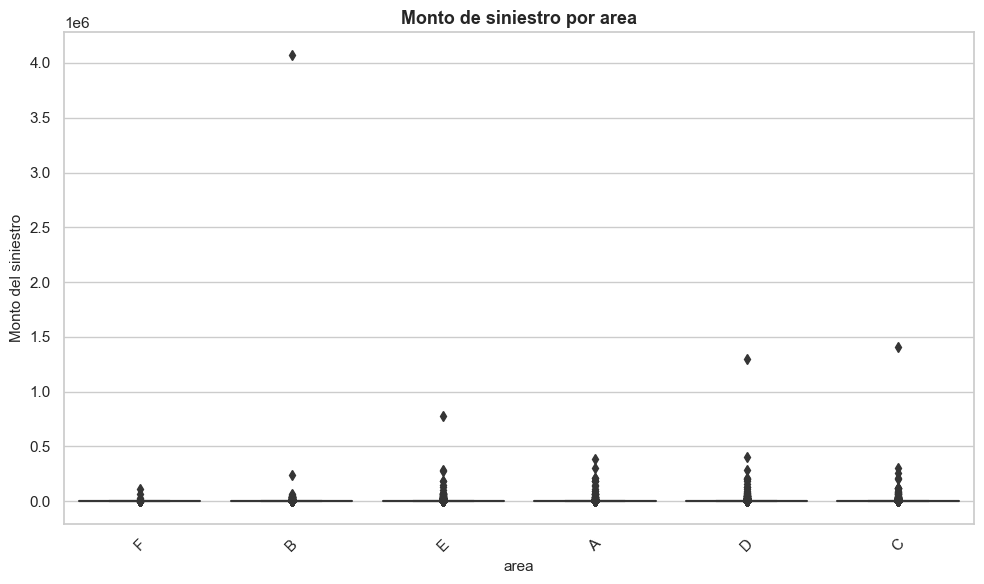

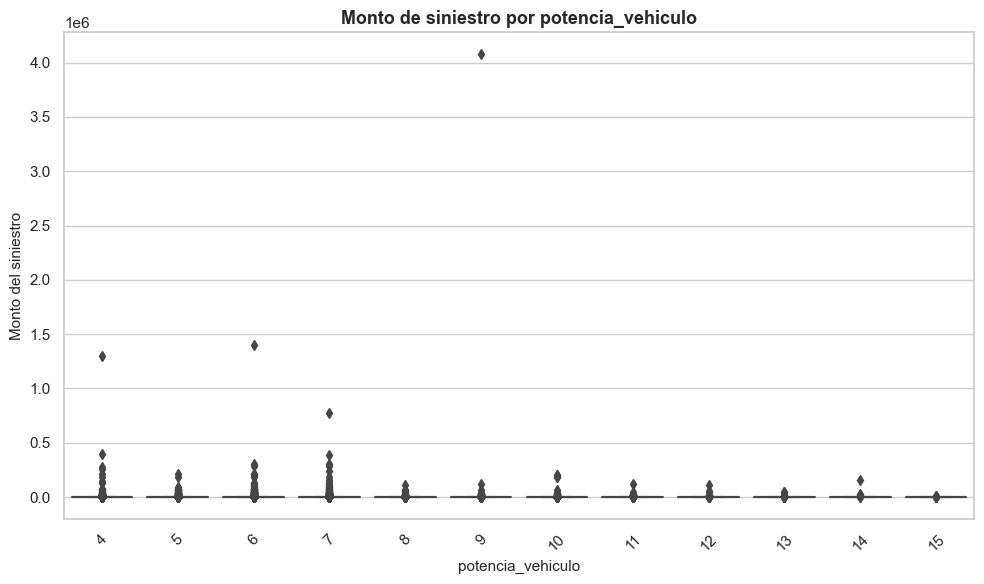

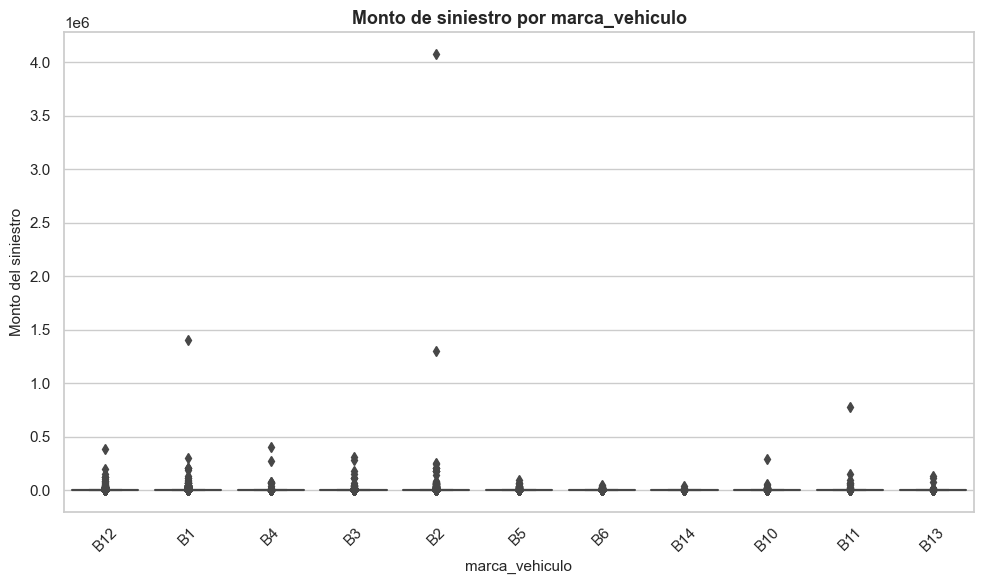

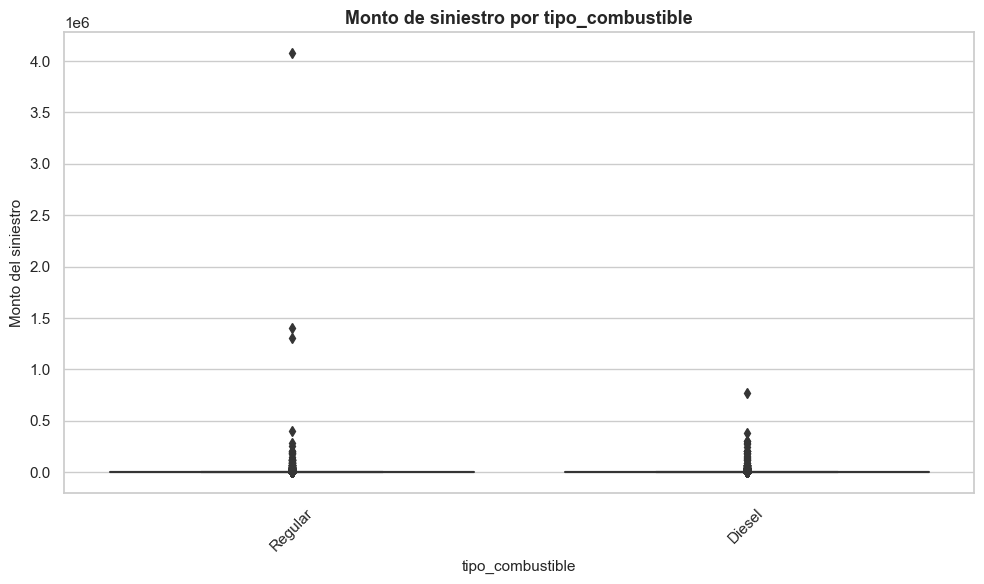

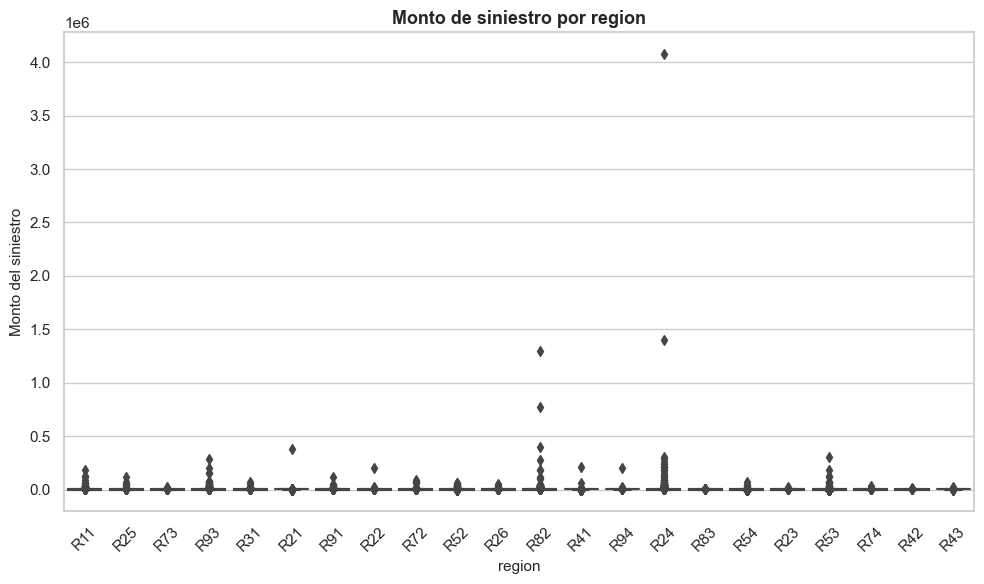

In [68]:
for var in categorical_sev:
    
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(
        data=df_sev_full,
        x=var,
        y="monto_siniestro"
    )
    
    plt.title(f"Monto de siniestro por {var}")
    plt.xlabel(var)
    plt.ylabel("Monto del siniestro")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

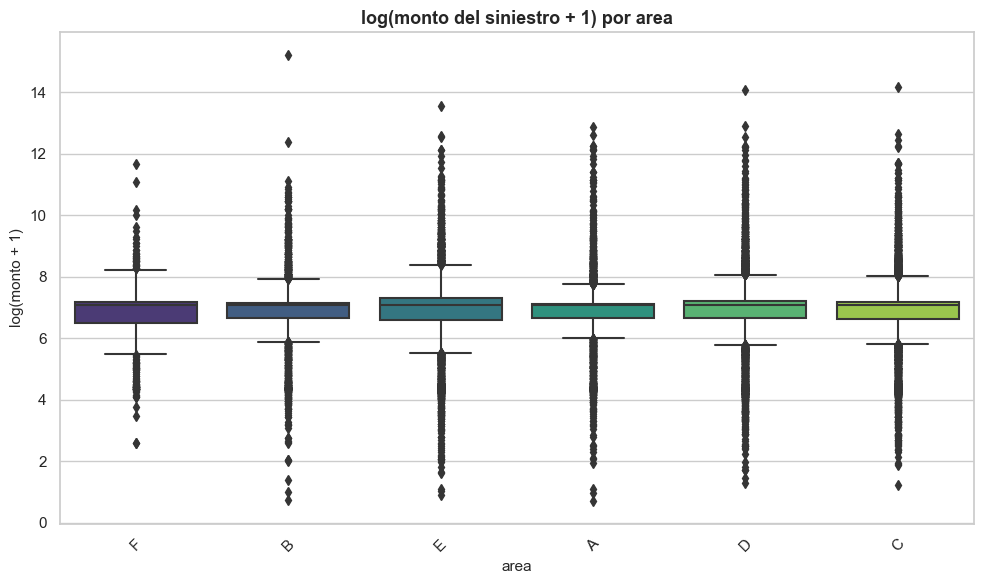

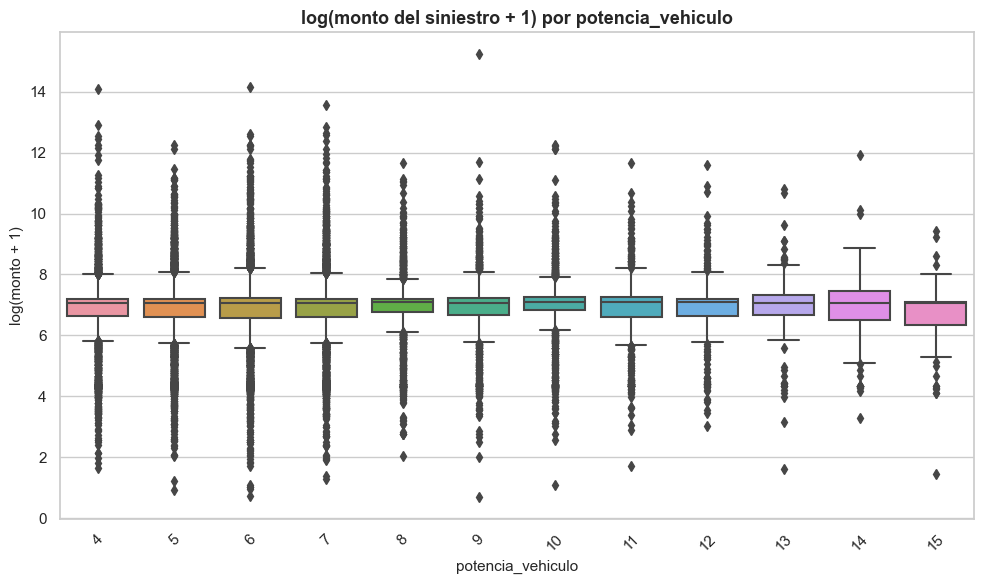

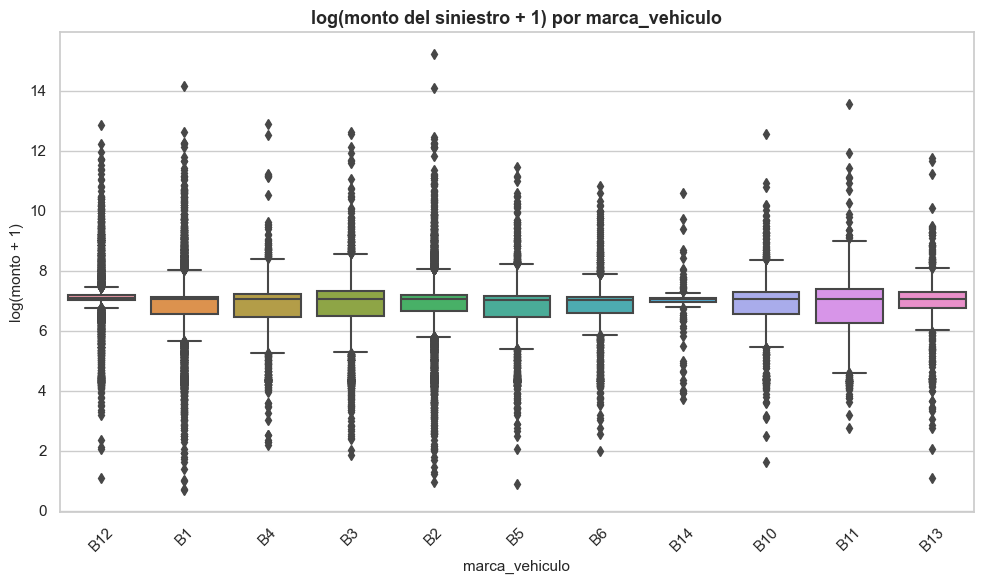

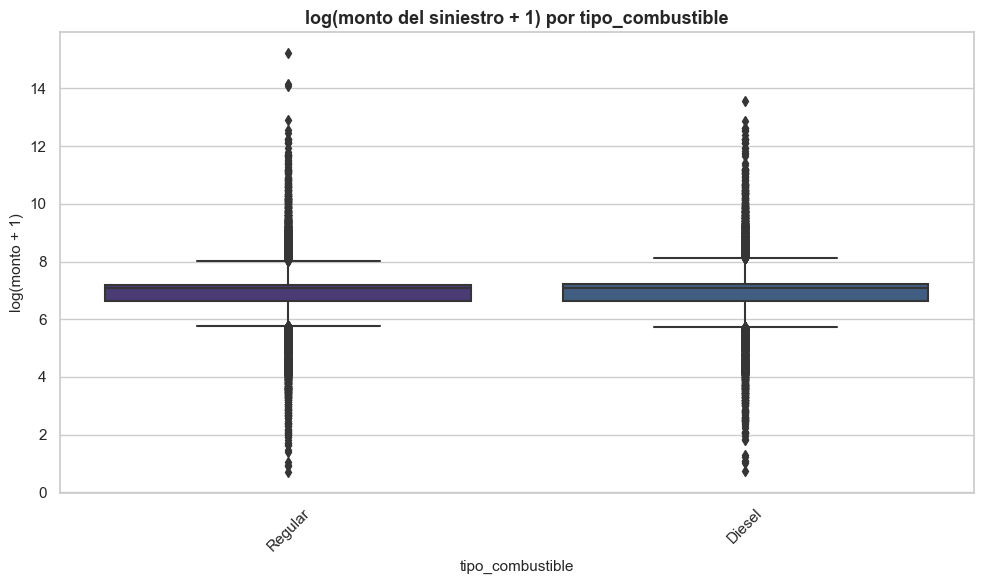

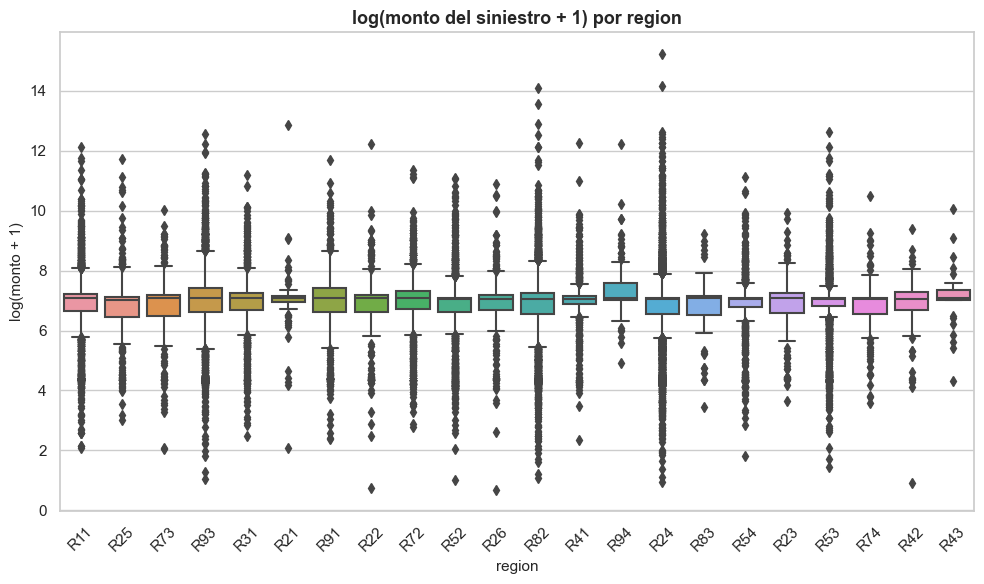

In [69]:
for var in categorical_sev:
    
    plt.figure(figsize=(10, 6))
    
    sns.boxplot(
        data=df_sev_full,
        x=var,
        y="log_monto_siniestro"
    )
    
    plt.title(
        f"log(monto del siniestro + 1) por {var}"
    )
    
    plt.xlabel(var)
    plt.ylabel("log(monto + 1)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Los boxplots en escala original muestran cajas visualmente comprimidas cerca de cero en todas las categorías, con una cantidad considerable de puntos marcados como atípicos por encima del bigote superior, resultado esperable dada la asimetría extrema ya documentada (asimetría de 106.14 en el análisis univariado). En la versión logarítmica, las cajas se vuelven comparables entre sí: se aprecia que la posición central (mediana) y la dispersión intercuartílica son bastante similares entre las categorías de una misma variable, reforzando lo observado en las estadísticas descriptivas, las diferencias entre categorías se concentran en la cola de valores altos (reflejada en la media y la desviación estándar), no en el comportamiento típico de la mayoría de los siniestros.

#### **Pruebas estadísticas**   

Se aplica la prueba de Kruskal-Wallis sobre "log_monto_siniestro" para contrastar si existen diferencias estadísticamente significativas en la severidad entre las categorías de cada variable. Se utiliza la variable transformada en lugar de la original para reducir la influencia desproporcionada de los valores extremos sobre el estadístico de prueba, manteniendo la naturaleza no paramétrica de la prueba, apropiada dado que la normalidad no se cumple ni siquiera después de la transformación logarítmica.

In [70]:
resultados_pruebas_sev = []

for var in categorical_sev:
    
    temp = df_sev_full[
        [var, "log_monto_siniestro"]
    ].dropna()
    
    grupos = [
        grupo["log_monto_siniestro"].values
        for _, grupo in temp.groupby(var)
    ]
    
    statistic, pvalue = stats.kruskal(
        *grupos
    )
    
    resultados_pruebas_sev.append({
        "variable": var,
        "prueba": "Kruskal-Wallis",
        "H": statistic,
        "p_value": pvalue,
        "num_grupos": len(grupos)
    })

pruebas_sev = pd.DataFrame(
    resultados_pruebas_sev
)

pruebas_sev

,variable,prueba,H,p_value,num_grupos
0,area,Kruskal-Wallis,15.2524,0.0093,6
1,potencia_vehiculo,Kruskal-Wallis,27.9180,0.0033,12
2,marca_vehiculo,Kruskal-Wallis,250.4618,0.0000,11
3,tipo_combustible,Kruskal-Wallis,4.7254,0.0297,2
4,region,Kruskal-Wallis,138.0729,0.0000,22


Los estadísticos H de Kruskal-Wallis en severidad son consistentemente menores que en frecuencia: "area" (15.25 vs 274.24), "potencia_vehiculo" (27.92 vs 154.33), "tipo_combustible" (4.73, p=0.0297, casi no significativo, vs 1,190.41) y "region" (138.07 vs 741.56). Solo "marca_vehiculo" se mantiene fuerte en ambos (250.46). En resumen: estas variables predicen mejor cuántos siniestros ocurren que cuánto cuestan.  

# 6. Conclusión  

El análisis bivariado permitió contrastar sistemáticamente las variables explicativas disponibles contra la frecuencia y la severidad de siniestralidad, revelando un comportamiento marcadamente distinto entre ambas dimensiones del riesgo.

En cuanto a frecuencia, ninguna variable numérica mostró una asociación monótona relevante con "tasa_frecuencia" (todos los coeficientes de Spearman por debajo de 0.06), pero las pruebas de Kruskal-Wallis y Mann-Whitney confirmaron diferencias estadísticamente significativas entre categorías en las cinco variables categóricas analizadas, siendo "marca_vehiculo" y "area" las que mostraron las señales más fuertes. Esto sugiere que, para el modelo de frecuencia, las variables categóricas aportarán más poder explicativo que las numéricas en su forma lineal o monótona directa, aunque será necesario explorar en la etapa de modelación si transformaciones no lineales, como tramos de edad o de bonus-malus, logran mejorar esta relación.

En cuanto a severidad, el patrón fue distinto y más débil: las correlaciones numéricas resultaron igual de bajas que en frecuencia, pero las pruebas categóricas mostraron estadísticos H considerablemente menores, y "tipo_combustible" apenas cruzó el umbral de significancia. Esto indica que el monto de un siniestro depende en menor medida de las características estructurales de la póliza, y más bien de factores no observados o aleatorios propios de cada evento, lo cual es consistente con la fuerte asimetría y la dominancia de valores extremos ya documentada, donde unos pocos siniestros catastróficos determinan las diferencias de medias entre categorías mientras que las medianas permanecen prácticamente iguales.

En conjunto, estos resultados anticipan una arquitectura de modelación diferenciada: por un lado, un modelo de frecuencia (GLM Poisson o similar) que puede apoyarse con mayor confianza en las variables categóricas disponibles; y por otro, un modelo de severidad (GLM Gamma o similar) donde el poder predictivo de estas mismas variables será más limitado, y donde el tratamiento de los valores extremos, ya sea mediante transformación logarítmica, recorte (capping) o distribuciones de cola pesada, será un factor determinante para la calidad del ajuste. Estos hallazgos constituyen así el punto de partida para la siguiente etapa del proyecto: el preprocesamiento de variables y la construcción de los modelos de frecuencia, severidad y prima pura.